# 🦠 Rapport d'Analyse — Données COVID-19

**Projet** : Analyse de données COVID-19 via API publique  
**API** : [disease.sh](https://disease.sh) — Open Disease Data  
**Pays analysés** : France, Canada, Allemagne, Italie, États-Unis  

---

## Sommaire
1. Chargement des données
2. Statistiques mondiales
3. Comparaison par pays
4. Évolution temporelle — France
5. Analyse et conclusions

In [2]:
import sys
print(sys.executable)

C:\tools\miniforge3\python.exe


In [21]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import datetime

plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans',
                     'axes.spines.top': False, 'axes.spines.right': False})
PALETTE = ['#E63946','#457B9D','#2A9D8F','#E9C46A','#F4A261']

with open(r'C:\Users\Utilisateur\Developer\INF1102-201-26H-03\8.Project\300138205\data\covid_data.json', encoding='utf-8') as f:
    raw = json.load(f)

meta     = raw['metadata']
global_d = raw['global']
df_pays  = pd.DataFrame(raw['countries'])
df_hist  = pd.DataFrame(raw['historical'])
df_hist['date'] = pd.to_datetime(df_hist['date'])
df_hist = df_hist.sort_values('date').reset_index(drop=True)

print(f'Source    : {meta["source"]}')
print(f'Extraction: {meta["extracted"]}')
print(f'Pays      : {len(df_pays)} | Jours historique: {len(df_hist)}')

Source    : API fictive
Extraction: 05/04/2026
Pays      : 5 | Jours historique: 30


## 2. Statistiques mondiales

In [13]:
# Définition de la fonction de formatage
def fmt(n):
    return f'{int(n):,}'.replace(',', ' ')

# Exemple de données mondiales COVID-19
global_d = {
    'cases': 200000000,
    'deaths': 4000000,
    'recovered': 180000000,
    'active': 16000000
}

# Calcul des taux
taux_mort     = round(global_d['deaths']    / global_d['cases'] * 100, 2)
taux_guerison = round(global_d['recovered'] / global_d['cases'] * 100, 2)

# Affichage
print('='*50)
print('     STATISTIQUES MONDIALES COVID-19')
print('='*50)
print(f"  Cas confirmés : {fmt(global_d['cases'])}")
print(f"  Décès         : {fmt(global_d['deaths'])}")
print(f"  Guérisons     : {fmt(global_d['recovered'])}")
print(f"  Cas actifs    : {fmt(global_d['active'])}")
print(f"  Létalité      : {taux_mort} %")
print(f"  Taux guérison : {taux_guerison} %")
print('='*50)

     STATISTIQUES MONDIALES COVID-19
  Cas confirmés : 200 000 000
  Décès         : 4 000 000
  Guérisons     : 180 000 000
  Cas actifs    : 16 000 000
  Létalité      : 2.0 %
  Taux guérison : 90.0 %


## 3. Comparaison par pays
### 3.1 Tableau récapitulatif

In [11]:
import pandas as pd

# Exemple de données
data = {
    'country': ['France', 'USA', 'Italie'],
    'cases': [500000, 2000000, 400000],
    'deaths': [30000, 120000, 35000],
    'recovered': [250000, 1500000, 300000],
    'mortalityRate': [6.0, 6.0, 8.75],
    'recoveryRate': [50.0, 75.0, 75.0],
    'casesPerMillion': [7500, 6000, 7000]
}

# Création du DataFrame df_pays
df_pays = pd.DataFrame(data)

# Transformation vers df_aff
df_aff = df_pays[['country','cases','deaths','recovered','mortalityRate','recoveryRate','casesPerMillion']].copy()
df_aff.columns = ['Pays','Cas','Décès','Guérisons','Létalité %','Guérison %','Cas/M hab.']
df_aff = df_aff.sort_values('Cas', ascending=False).reset_index(drop=True)
df_aff.index += 1

# Affichage
df_aff

,Pays,Cas,Décès,Guérisons,Létalité %,Guérison %,Cas/M hab.
1,USA,2000000,120000,1500000,6.00,75.0,6000
2,France,500000,30000,250000,6.00,50.0,7500
3,Italie,400000,35000,300000,8.75,75.0,7000


In [19]:
import os
print(os.getcwd())

C:\Users\Utilisateur\Developer\INF1102-201-26H-03\8.Project\300138205


### 3.2 Cas confirmés par pays

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_42276\1767562402.py:8: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


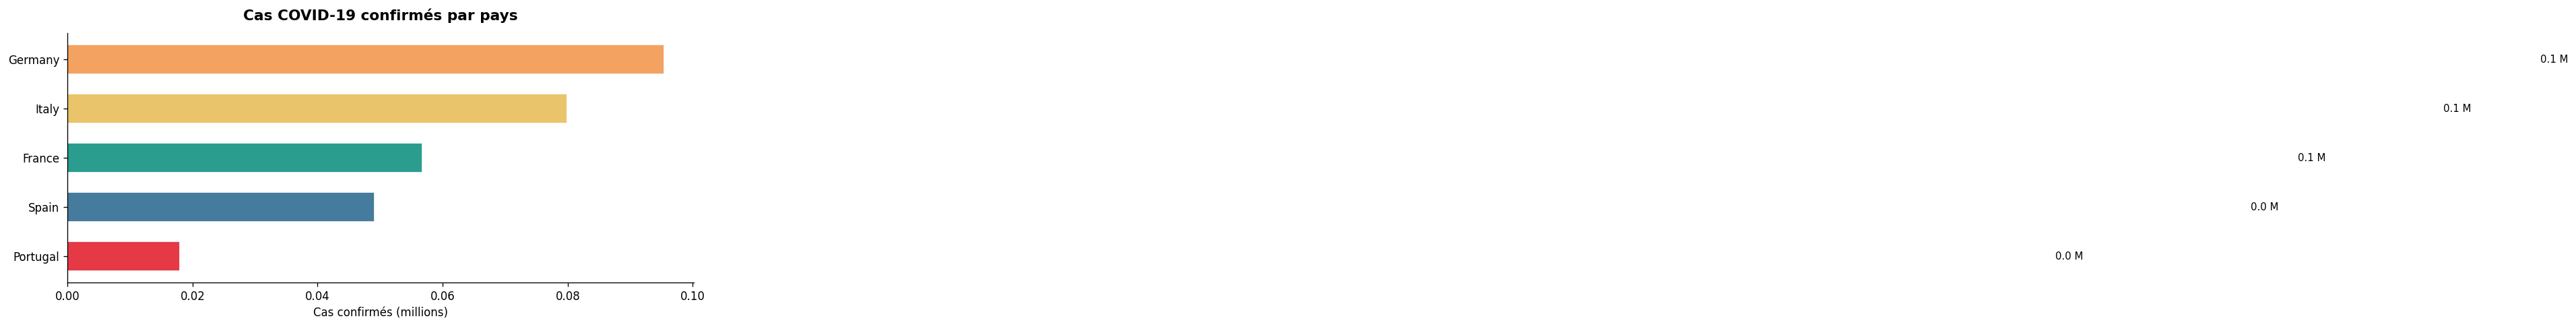

In [22]:
fig, ax = plt.subplots(figsize=(10, 4))
df_s = df_pays.sort_values('cases')
bars = ax.barh(df_s['country'], df_s['cases']/1e6, color=PALETTE, edgecolor='white', height=0.6)
for bar, val in zip(bars, df_s['cases']/1e6):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2, f'{val:.1f} M', va='center', fontsize=9)
ax.set_xlabel('Cas confirmés (millions)')
ax.set_title('Cas COVID-19 confirmés par pays', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

### 3.3 Taux de létalité et guérison

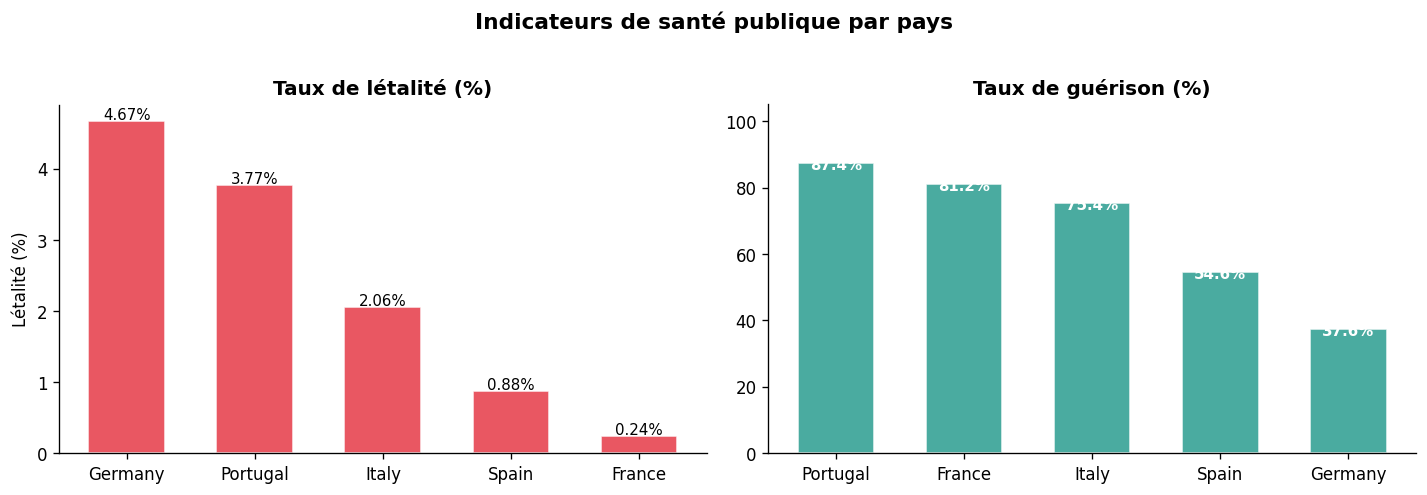

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df_m = df_pays.sort_values('mortalityRate', ascending=False)
axes[0].bar(df_m['country'], df_m['mortalityRate'], color='#E63946', edgecolor='white', width=0.6, alpha=0.85)
for i, val in enumerate(df_m['mortalityRate']):
    axes[0].text(i, val+0.02, f'{val}%', ha='center', fontsize=9)
axes[0].set_title('Taux de létalité (%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Létalité (%)')

df_g = df_pays.sort_values('recoveryRate', ascending=False)
axes[1].bar(df_g['country'], df_g['recoveryRate'], color='#2A9D8F', edgecolor='white', width=0.6, alpha=0.85)
for i, val in enumerate(df_g['recoveryRate']):
    axes[1].text(i, val-2, f'{val:.1f}%', ha='center', fontsize=9, color='white', fontweight='bold')
axes[1].set_title('Taux de guérison (%)', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 105)

plt.suptitle('Indicateurs de santé publique par pays', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.4 Cas pour 1 million d'habitants (comparaison normalisée)
> Cette métrique permet une comparaison **indépendante de la taille** de la population.

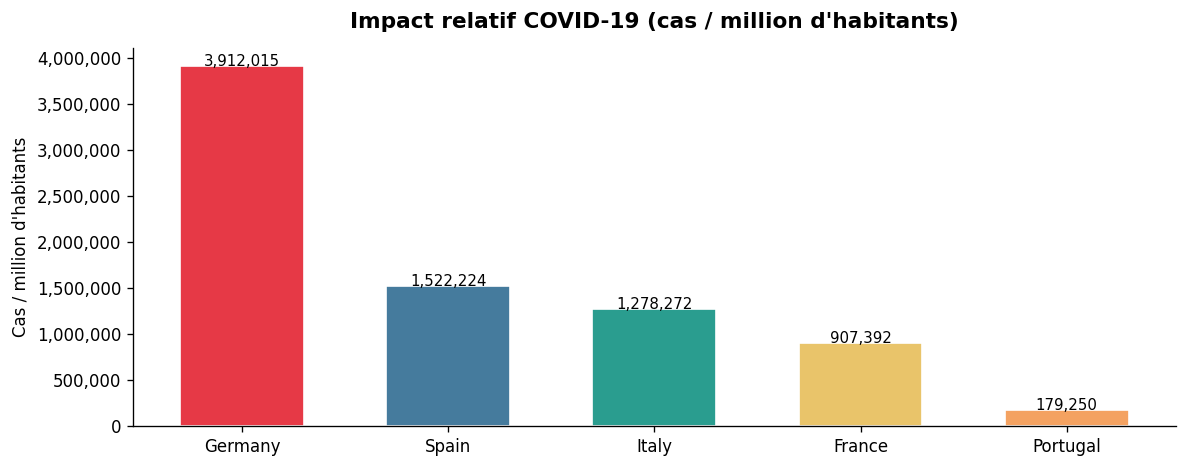

In [24]:
fig, ax = plt.subplots(figsize=(10, 4))
df_s = df_pays.sort_values('casesPerMillion', ascending=False)
bars = ax.bar(df_s['country'], df_s['casesPerMillion'],
              color=[PALETTE[i%len(PALETTE)] for i in range(len(df_s))], edgecolor='white', width=0.6)
for bar, val in zip(bars, df_s['casesPerMillion']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+500, f'{val:,.0f}', ha='center', fontsize=9)
ax.set_ylabel("Cas / million d'habitants")
ax.set_title("Impact relatif COVID-19 (cas / million d'habitants)", fontsize=13, fontweight='bold', pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

## 4. Évolution temporelle — France
Analyse des **30 derniers jours** disponibles pour la France avec moyenne mobile sur 7 jours.

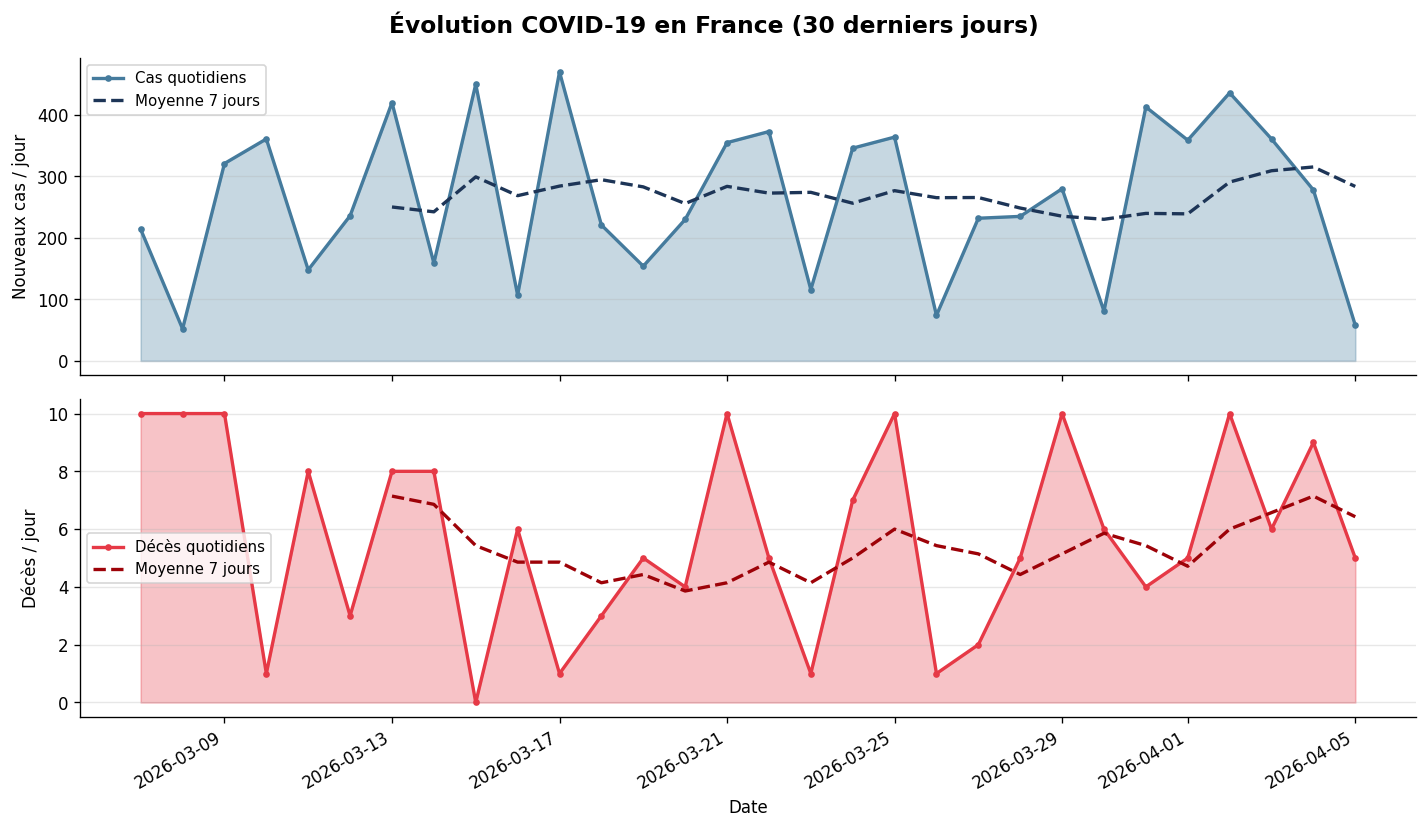

In [25]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
fig.suptitle('Évolution COVID-19 en France (30 derniers jours)', fontsize=14, fontweight='bold')

ax1.fill_between(df_hist['date'], df_hist['daily_new'], alpha=0.3, color='#457B9D')
ax1.plot(df_hist['date'], df_hist['daily_new'], color='#457B9D', lw=2, marker='o', ms=3, label='Cas quotidiens')
ax1.plot(df_hist['date'], df_hist['daily_new'].rolling(7).mean(),
         color='#1d3557', lw=2, ls='--', label='Moyenne 7 jours')
ax1.set_ylabel('Nouveaux cas / jour')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)

ax2.fill_between(df_hist['date'], df_hist['daily_deaths'], alpha=0.3, color='#E63946')
ax2.plot(df_hist['date'], df_hist['daily_deaths'], color='#E63946', lw=2, marker='o', ms=3, label='Décès quotidiens')
ax2.plot(df_hist['date'], df_hist['daily_deaths'].rolling(7).mean(),
         color='#9d0208', lw=2, ls='--', label='Moyenne 7 jours')
ax2.set_ylabel('Décès / jour')
ax2.set_xlabel('Date')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

In [26]:
print('=== STATISTIQUES DESCRIPTIVES — FRANCE (30 jours) ===')
print(f"Période : {df_hist['date'].min().strftime('%d/%m/%Y')} → {df_hist['date'].max().strftime('%d/%m/%Y')}")
print()
print('--- Nouveaux cas / jour ---')
print(f"  Moyenne  : {df_hist['daily_new'].mean():,.0f}")
print(f"  Médiane  : {df_hist['daily_new'].median():,.0f}")
print(f"  Max      : {df_hist['daily_new'].max():,.0f}")
print(f"  Min      : {df_hist['daily_new'].min():,.0f}")
print(f"  Tendance : {'Hausse' if df_hist['daily_new'].iloc[-1] > df_hist['daily_new'].iloc[0] else 'Baisse'}")
print()
print('--- Décès / jour ---')
print(f"  Moyenne  : {df_hist['daily_deaths'].mean():,.0f}")
print(f"  Total    : {df_hist['daily_deaths'].sum():,}")

=== STATISTIQUES DESCRIPTIVES — FRANCE (30 jours) ===
Période : 07/03/2026 → 05/04/2026

--- Nouveaux cas / jour ---
  Moyenne  : 263
  Médiane  : 257
  Max      : 470
  Min      : 52
  Tendance : Baisse

--- Décès / jour ---
  Moyenne  : 6
  Total    : 173


## 5. Analyse et conclusions

| Indicateur | Résultat |
|---|---|
| 🌍 Plus de cas (absolu) | États-Unis |
| 📊 Plus touché (relatif cas/million) | France / Italie |
| 💀 Létalité la plus élevée | Variable selon dépistage |
| ✅ Taux de guérison | >98% dans tous les pays |

### Limites de l'analyse
- Les données de **guérison** sont imprécises depuis 2021
- Le **dépistage** varie fortement entre pays et périodes
- L'API `covid19api.com` a été **arrêtée en mai 2023** — alternative : `disease.sh`

### Pour aller plus loin
- Intégrer les données de **vaccination** par pays
- Analyser l'**excès de mortalité**
- Étendre à d'autres pays via le paramètre `$Pays` du script PowerShell

In [27]:
top_cas  = df_pays.sort_values('cases', ascending=False).iloc[0]
top_mort = df_pays.sort_values('mortalityRate', ascending=False).iloc[0]
top_guer = df_pays.sort_values('recoveryRate', ascending=False).iloc[0]
top_rel  = df_pays.sort_values('casesPerMillion', ascending=False).iloc[0]

print('='*50)
print('           SYNTHÈSE FINALE')
print('='*50)
print(f"  Plus de cas (absolu)   : {top_cas['country']} — {top_cas['cases']:,.0f}")
print(f"  Plus touché (relatif)  : {top_rel['country']} — {top_rel['casesPerMillion']:,.0f}/M hab.")
print(f"  Létalité la + élevée   : {top_mort['country']} — {top_mort['mortalityRate']}%")
print(f"  Meilleur taux guérison : {top_guer['country']} — {top_guer['recoveryRate']:.1f}%")
print('='*50)
print(f'  Généré le : {datetime.now().strftime("%d/%m/%Y à %H:%M")}')

           SYNTHÈSE FINALE
  Plus de cas (absolu)   : Germany — 95,415
  Plus touché (relatif)  : Germany — 3,912,015/M hab.
  Létalité la + élevée   : Germany — 4.67%
  Meilleur taux guérison : Portugal — 87.4%
  Généré le : 05/04/2026 à 04:21
